# Lecture 23: Deep learning, optimizing manufacturing of concrete
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/natrask/engr1050-fall2026/blob/main/NewMaterial/Lecture23/lec23.ipynb)


## Overview

In the last lecture, we showed how to optimize a function using Newton's method. We saw that *if we know how to compute the derivative of a function*, we can use Newton to find roots. 

Today we will use PyTorch to learn how to automatically take derivatives of functions. Once we have that ingredient, we will have everything we need to minimize objectives that depend on complicated functions (like a neural network). Once you complete todays tutorial you will know enough to do some real machine learning next week.

In [ ]:
# First, let's import PyTorch
import torch
print("PyTorch version:", torch.__version__)

# Check if PyTorch is working
test_tensor = torch.tensor([1.0, 2.0, 3.0])
print("Test tensor:", test_tensor)

# Introducing `modelClass` to define models that we will fit to data

Last week we saw how to use `modelClass` to construct different kinds of functions (like polynomials or a strain-hardening law) to data. Today we will use the exact same code to build a **multilayer perceptron** or **MLP**. The equation for an MLP consisting of $N$ layers is given by

$$
\begin{align*}
\mathbf{h}_1 &= \sigma(\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1) \\
\mathbf{h}_2 &= \sigma(\mathbf{W}_2 \mathbf{h}_1 + \mathbf{b}_2) \\
&\vdots \\
\mathbf{h}_N &= \sigma(\mathbf{W}_N \mathbf{h}_{N-1} + \mathbf{b}_N) \\
\mathbf{y} &= \mathbf{W}_{out} \mathbf{h}_N
\end{align*}
$$

Let's break down what the different parts of this mean:

- $\mathbf{x}$ is the input, and we will take that as a vector of dimension $d$
- $\mathbf{h}_i$ standard for the $i^{th}$ hidden layer of the network, and will be a vector of dimension $N_n$ (often interpreted as the number of artificial neurons per layer)
- $\mathbf{W}_i$ and $\mathbf{b}_i$ are the *weights* and *biases* of each layer. These are the **learnable parameters** in the model, and are what we will update with gradient descent.
- The function $\sigma$ is called an *activation function*. It is meant to mimic the firing of neurons once the input reaches a given size.
- The final layer is called a *linear layer*. It reshapes the final output to match the desired dimension for the output.

When you're doing machine learning, the trickiest part is just making sure that everything is the right shape. Remember that for a matrix to map from a vector of length $n$ to a vector of length $m$, it needs to be a $m \times n$ sized matrix. This implies that:
- $\mathbf{W}_1$ is $N_n \times d$ so bring the input dimension up to the hidden dimension
- $\mathbf{W}_2 \dots W_N$ are $N_n \times N_n$ so that the hidden layers all have the same dimension
- $\mathbf{b}_i$ is a vector of length $N_n$ so that it makes sense to add it to the corresponding $\mathbf{h}_i$
- If we want the neural network to output a scalar, then $\mathbf{W}_{out}$ should be $1 \times N_n$

When choosing an activation function, the most common is the **Rectified Linear unit (ReLU)**.

$$
\text{ReLU}(x) = \max(0, x) = \begin{cases}
x & \text{if } x > 0 \\
0 & \text{if } x \leq 0
\end{cases}
$$

A ReLU will let information pass through if the input is positive, otherwise it will switch to zero. This is meant to mimic the way a real neuron will fire if the input is great than some potential - the bias $\mathbf{b}_i$ represents that potential.

While ReLU is a classic choice and has a clear biological interpretation, you can choose any nonlinear function. A common one is to use the *tanh* function, which gives nice smooth outputs that are good for regressing continuous functions.

$$
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} = \frac{e^{2x} - 1}{e^{2x} + 1}
$$

## Build our multilayer perceptron class

Now, let's implement this in our `modelClass`. To make it easy to compare, I've copied below the original `modelClass` we used last week for linear regression.

In [ ]:
class modelClass:
    def __init__(self, a0, b0):
        # Initialize a linear model y = a*x + b
        # a0 - (float) initial value for slope
        # b0 - (float) initial value for intercept

        self.a = torch.tensor(a0, requires_grad=True)
        self.b = torch.tensor(b0, requires_grad=True)
    
    def forward(self, x):
        # Given input x (assumed to be a scalar shape torch tensor), return predicted y = a*x+b
        return self.a * x + self.b

Next, I've modified this to implement A simple MLP.
- I added the trainable variables to the input (weights and biases). To give some initial values, I use `torch.randn` to sample the entries of each matrix from a random unit normal distribution.
- I added input parameters `input_dim`, `hidden_dim`, and `output_dim` so that the user can specify the shapes of the input and output as well as how many neurons will be in the network.
- I modified the `forward` function to evaluate the network, using a `tanh` activation. 

In here I use `self.W1 @ x`. An \@ symbol is Numpy and pytorch shorthand for "do a matrix multiplication". This makes the code easier to read like a math formula..

In [1]:
class MLP_modelClass:
    def __init__(self, input_dim, hidden_dim, output_dim):
        # Initialize a 2-layer MLP
        # input_dim - dimension of input (e.g., 1 for scalar input)
        # hidden_dim - number of neurons in hidden layer
        # output_dim - dimension of output (e.g., 1 for scalar output)
        
        # Layer 1: input -> hidden
        self.W1 = torch.randn(hidden_dim, input_dim, requires_grad=True)
        self.b1 = torch.randn(hidden_dim, requires_grad=True)
        
        # Layer 2: hidden -> output
        self.W2 = torch.randn(output_dim, hidden_dim, requires_grad=True)
        self.b2 = torch.randn(output_dim, requires_grad=True)
    
    def forward(self, x):
        # Layer 1: compute h1 = tanh(W1*x + b1)
        z1 = self.W1 @ x + self.b1   # Linear transformation
        h1 = torch.tanh(z1)          # Activation function
        
        # Layer 2: compute y = W2*h1 + b2
        y = self.W2 @ h1 + self.b2   # Linear transformation (no activation on output)
        
        return y

# Example: Simple regression

Same as last class, let me put together some simple synthetic data by adding noise to a function, and then we'll see how to fit the neural network to the function

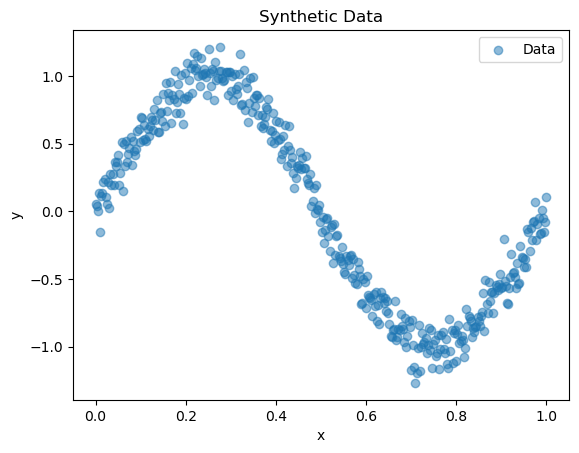

In [3]:
# Generate some synthetic data to fit a linear model to
import torch

x_data = torch.linspace(0, 1, steps=400)
y_data = torch.sin( 2.0*torch.pi*x_data) + torch.randn(x_data.size()) * 0.1  

import matplotlib.pyplot as plt
plt.scatter(x_data.numpy(), y_data.numpy(), label='Data', alpha=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Synthetic Data')
plt.legend()
plt.show()

In [15]:
# Initialize MLP model
model = MLP_modelClass(input_dim=1, hidden_dim=40, output_dim=1)

# Training parameters
learning_rate = 0.0001
num_steps = 4000

for step in range(num_steps):
    # Zero gradients at the start of each step
    if model.W1.grad is not None:
        model.W1.grad.zero_()
        model.b1.grad.zero_()
        model.W2.grad.zero_()
        model.b2.grad.zero_()
    
    # Accumulate loss as a tensor
    total_loss = torch.tensor(0.0, requires_grad=True)
    
    for i in range(len(x_data)):
        x = torch.tensor([x_data[i].item()], dtype=torch.float32)  # Convert to 1D vector
        y_true = torch.tensor([y_data[i].item()], dtype=torch.float32)  # Convert to 1D vector
        
        # Forward pass
        y_pred = model.forward(x)
        
        # Compute loss and add to total (keep as tensor)
        loss = (y_pred - y_true)**2
        total_loss = total_loss + loss.sum()
    
    # Backward pass on the accumulated loss
    total_loss.backward()
    
    # Update parameters
    with torch.no_grad():
        model.W1 -= learning_rate * model.W1.grad
        model.b1 -= learning_rate * model.b1.grad
        model.W2 -= learning_rate * model.W2.grad
        model.b2 -= learning_rate * model.b2.grad
    
    # Print progress every 100 steps
    if step % 100 == 0:
        print(f"Step {step}, Avg Loss: {total_loss.item()/len(x_data):.4f}")

Step 0, Avg Loss: 1.5211
Step 100, Avg Loss: 0.1786
Step 200, Avg Loss: 0.1696
Step 300, Avg Loss: 0.1621
Step 400, Avg Loss: 0.1553
Step 500, Avg Loss: 0.1485
Step 600, Avg Loss: 0.1416
Step 700, Avg Loss: 0.1345
Step 800, Avg Loss: 0.1271
Step 900, Avg Loss: 0.1196
Step 1000, Avg Loss: 0.1119
Step 1100, Avg Loss: 0.1041
Step 1200, Avg Loss: 0.0962
Step 1300, Avg Loss: 0.0883
Step 1400, Avg Loss: 0.0806
Step 1500, Avg Loss: 0.0731
Step 1600, Avg Loss: 0.0660
Step 1700, Avg Loss: 0.0594
Step 1800, Avg Loss: 0.0534
Step 1900, Avg Loss: 0.0480
Step 2000, Avg Loss: 0.0432
Step 2100, Avg Loss: 0.0390
Step 2200, Avg Loss: 0.0354
Step 2300, Avg Loss: 0.0324
Step 2400, Avg Loss: 0.0298
Step 2500, Avg Loss: 0.0277
Step 2600, Avg Loss: 0.0259
Step 2700, Avg Loss: 0.0243
Step 2800, Avg Loss: 0.0230
Step 2900, Avg Loss: 0.0219
Step 3000, Avg Loss: 0.0209
Step 3100, Avg Loss: 0.0200
Step 3200, Avg Loss: 0.0192
Step 3300, Avg Loss: 0.0186
Step 3400, Avg Loss: 0.1897
Step 3500, Avg Loss: 0.0243
Step

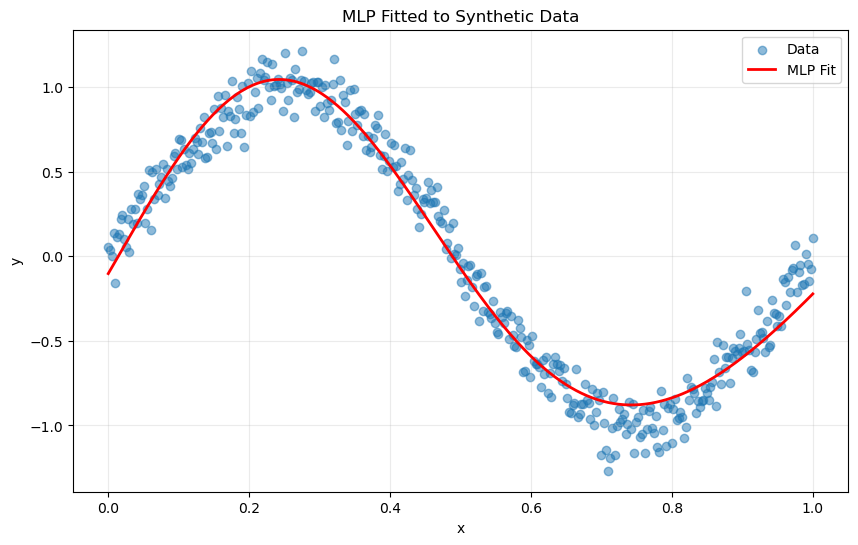

In [ ]:
# Prompt: Plot the fitted neural network against the data
plt.figure(figsize=(10, 6))

# Plot original noisy data
plt.scatter(x_data.numpy(), y_data.numpy(), label='Data', alpha=0.5)

# Generate predictions from the trained model
x_plot = torch.linspace(0, 1, steps=400)
y_pred = []
for i in range(len(x_plot)):
    x = torch.tensor([x_plot[i].item()], dtype=torch.float32)
    y = model.forward(x)
    y_pred.append(y.detach().item())  # Use detach() to remove from computational graph

# Plot the neural network prediction
plt.plot(x_plot.numpy(), y_pred, 'r-', label='MLP Fit', linewidth=2)

plt.xlabel('x')
plt.ylabel('y')
plt.title('MLP Fitted to Synthetic Data')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## Stochastic gradient descent and minibatching

It turns out that it is much faster to train using *stochastic gradient descent*. Instead of evaluating the model on the entire dataset and computing a gradient update on everything all at once (that's a big computational graph!), instead we can randomly grab a smaller collection of training points from the dataset, do an update on it, and then repeat so we don't process so much all at once. This fits more nicely into your computers memory and processor so that it goes faster.

We call this `minibatching`. The number of points that you grab is called a `batch`. It will introduce another parameter called `batch_size` in addition to the `learning_rate` that you'll need to wrestle with. You may come to dislike this about machine learning - there are loads of parameters that just need to get dialed in for everything to work (this is a lot of why these models are so wasteful, they need to be trained many times to figure out a good problem setup that works). 

It turns out that minibatching will make a model not just train faster, but also to get a better fit. This is because if the model gets stuck in a bad local minimizer, you can randomly pick a minibatch whose gradient knocks it out of the little valley that it's trapped in.

In [28]:
# Initialize MLP model
model = MLP_modelClass(input_dim=1, hidden_dim=40, output_dim=1)

# Training parameters
learning_rate = 0.001
num_steps = 20000
batch_size = 10

for step in range(num_steps):
    # Zero gradients at the start of each step
    if model.W1.grad is not None:
        model.W1.grad.zero_()
        model.b1.grad.zero_()
        model.W2.grad.zero_()
        model.b2.grad.zero_()
    
    # Accumulate loss as a tensor
    total_loss = torch.tensor(0.0, requires_grad=True)
    
    # Randomly select batch_size data points
    for j in range(batch_size):
        i = torch.randint(0, len(x_data), (1,)).item()
        
        x = torch.tensor([x_data[i].item()], dtype=torch.float32)
        y_true = torch.tensor([y_data[i].item()], dtype=torch.float32)
        
        # Forward pass
        y_pred = model.forward(x)
        
        # Compute loss and add to total (keep as tensor)
        loss = (y_pred - y_true)**2
        total_loss = total_loss + loss.sum()
    
    # Backward pass on the accumulated loss
    total_loss.backward()
    
    # Update parameters
    with torch.no_grad():
        model.W1 -= learning_rate * model.W1.grad
        model.b1 -= learning_rate * model.b1.grad
        model.W2 -= learning_rate * model.W2.grad
        model.b2 -= learning_rate * model.b2.grad
    
    # Print progress every 100 steps
    if step % 100 == 0:
        print(f"Step {step}, Avg Loss: {total_loss.item()/batch_size:.4f}")

        #loss on entire dataset
        total_loss = torch.tensor(0.0, requires_grad=False)
        for i in range(len(x_data)):
            x = torch.tensor([x_data[i].item()], dtype=torch.float32)
            y_true = torch.tensor([y_data[i].item()], dtype=torch.float32)
            
            # Forward pass
            y_pred = model.forward(x)
            
            # Compute loss and add to total
            loss = (y_pred - y_true)**2
            total_loss = total_loss + loss.sum()
        print(f"Final Avg Loss on entire dataset: {total_loss.item()/len(x_data):.4f}")

Step 0, Avg Loss: 29.9107
Final Avg Loss on entire dataset: 4.7883
Step 100, Avg Loss: 0.1154
Final Avg Loss on entire dataset: 0.1975
Step 200, Avg Loss: 0.2246
Final Avg Loss on entire dataset: 0.2113
Step 300, Avg Loss: 0.0905
Final Avg Loss on entire dataset: 0.1871
Step 400, Avg Loss: 0.2099
Final Avg Loss on entire dataset: 0.2157
Step 500, Avg Loss: 0.2014
Final Avg Loss on entire dataset: 0.1999
Step 600, Avg Loss: 0.2461
Final Avg Loss on entire dataset: 0.1878
Step 700, Avg Loss: 0.1788
Final Avg Loss on entire dataset: 0.1815
Step 800, Avg Loss: 0.0935
Final Avg Loss on entire dataset: 0.2117
Step 900, Avg Loss: 0.1308
Final Avg Loss on entire dataset: 0.1763
Step 1000, Avg Loss: 0.2908
Final Avg Loss on entire dataset: 0.1804
Step 1100, Avg Loss: 0.0929
Final Avg Loss on entire dataset: 0.1724
Step 1200, Avg Loss: 0.1325
Final Avg Loss on entire dataset: 0.1728
Step 1300, Avg Loss: 0.3276
Final Avg Loss on entire dataset: 0.1725
Step 1400, Avg Loss: 0.2276
Final Avg Loss on

**Visualize.** Same as before, we can plot our prediction

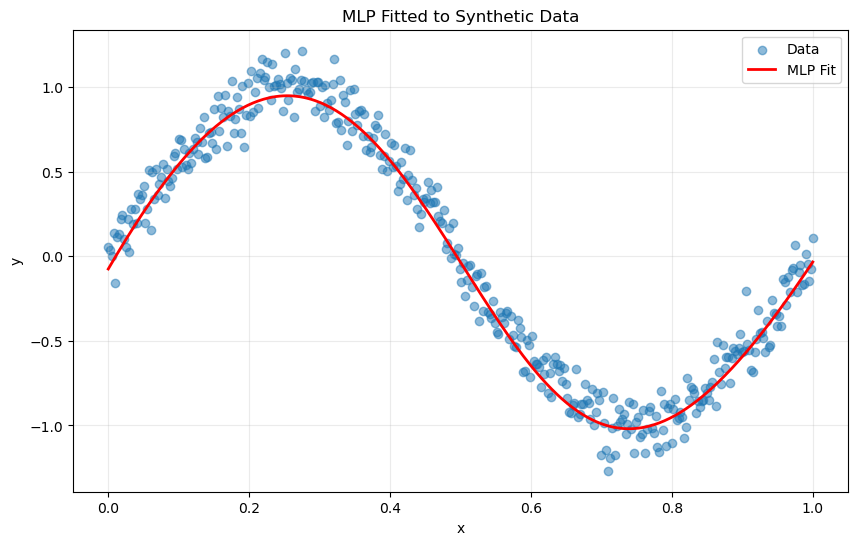

In [ ]:
# Prompt: Plot the fitted neural network against the data

plt.figure(figsize=(10, 6))

# Plot original noisy data
plt.scatter(x_data.numpy(), y_data.numpy(), label='Data', alpha=0.5)

# Generate predictions from the trained model
x_plot = torch.linspace(0, 1, steps=400)
y_pred = []
for i in range(len(x_plot)):
    x = torch.tensor([x_plot[i].item()], dtype=torch.float32)
    y = model.forward(x)
    y_pred.append(y.detach().item())  # Use detach() to remove from computational graph

# Plot the neural network prediction
plt.plot(x_plot.numpy(), y_pred, 'r-', label='MLP Fit', linewidth=2)

plt.xlabel('x')
plt.ylabel('y')
plt.title('MLP Fitted to Synthetic Data')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## Interact with the code to learn how to make modifications:
Modify the `MLP_modelClass` so that there are two hidden layers, and so that it uses the ReLU activation instead of the tanh. To do this you can use `torch.relu` in the exact same way that we used `torch.tanh`.

You'll need a new weight and biases matrix for the new hidden layer. To do that:
- Add the new tensors to the initializer
- Modify the forward pass to include the extra layer
- Update the gradient updates in the training loop so that they are updated along with the old ones

In [ ]:
# TODO - make a two hidden layer MLP with ReLU activations

# Today's exercise: machine learn how to manufacture concrete

In real-life engineering, it is extremely common that you will be presented with a problem that is not "nice" - there will be many inputs that could potentially influence an output, and your job will depend on making a prediction even though the data you have is messy.

I've picked out a dataset that maps onto this. Concrete is arguably the most important engineering material, but has a huge number of factors that can impact its strength: many ingredients get mixed together, and the process for how to combine them has a huge number of factors. If you cook, you probably have a good sense for how a small squeeze of lemon or a little too much flour can drastically change the end result - it's no different with concrete.

First I'll step through the dataset so you can get a little intuition for what we're looking at. Step one whenever someone gives you data is to visualize it and try to make sense of what you've got. Then we'll feed it through an MLP and see that we can get a surprisingly good prediction of concrete strength from what looks like a random soup of information.

## Dataset description

**Concrete Compressive Strength Data Set**

I-Cheng Yeh, "Modeling of strength of high performance concrete using artificial neural networks," Cement and Concrete Research, Vol. 28, No. 12, pp. 1797-1808 (1998).

**Source:** UCI Machine Learning Repository  
**URL:** https://archive.ics.uci.edu/ml/datasets/Concrete+Compressive+Strength

**Additional Reference:**
Dua, D. and Graff, C. (2019). UCI Machine Learning Repository [http://archive.ics.uci.edu/ml]. Irvine, CA: University of California, School of Information and Computer Science.


The dataset contains 8 input features that describe the composition and age of concrete samples:

1. **Cement (kg/m³)** - Amount of Portland cement in the concrete mixture. Cement is the binding agent that holds the concrete together.

2. **Blast Furnace Slag (kg/m³)** - A byproduct from iron production used as a supplementary cementitious material. It can partially replace cement and improve durability.

3. **Fly Ash (kg/m³)** - Fine powder byproduct from coal combustion in power plants. Used as a partial cement replacement to improve workability and long-term strength.

4. **Water (kg/m³)** - Amount of water in the mixture. The water-to-cement ratio is critical for strength - too much weakens the concrete, too little makes it unworkable.

5. **Superplasticizer (kg/m³)** - Chemical additive that improves the flowability of concrete without adding extra water. Allows for easier pouring and better compaction.

6. **Coarse Aggregate (kg/m³)** - Larger particles like gravel or crushed stone (typically > 4.75mm). Provides structural strength and bulk to the concrete.

7. **Fine Aggregate (kg/m³)** - Smaller particles like sand (typically < 4.75mm). Fills voids between coarse aggregate and improves workability.

8. **Age (days)** - Time since the concrete was cast. Concrete continues to gain strength over time as the cement hydration process continues (typically measured at 1, 7, 28, or 90 days).

**Target Variable:** **Compressive Strength (MPa)** - The maximum stress the concrete can withstand before failing under compression, measured in megapascals.

## Load the dataset

Running the following code will download the data off the internet. 

**Pro tip:** You'll see a line with a `# Standardize` comment. Neural networks always work much better if you do gradient descent in units where everything is always order one - I took care of this by scaling each input and output variable by their standard deviations to get something one-ish.

In [30]:
# Load concrete strength data
import pandas as pd

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls'
df = pd.read_excel(url)

# Convert to PyTorch tensors
import torch

# Normalize features
X = torch.tensor(df.iloc[:, :-1].values, dtype=torch.float32)
X = (X - X.mean(dim=0)) / X.std(dim=0)  # Standardize

# Target variable
y = torch.tensor(df.iloc[:, -1].values, dtype=torch.float32).reshape(-1, 1)

print(f"Dataset size: {len(X)} samples")
print(f"Input features: {X.shape[1]}")
print(f"Features: Cement, Blast Furnace Slag, Fly Ash, Water, Superplasticizer, Coarse Aggregate, Fine Aggregate, Age")
print(f"Target: Compressive Strength (MPa)")

Dataset size: 1030 samples
Input features: 8
Features: Cement, Blast Furnace Slag, Fly Ash, Water, Superplasticizer, Coarse Aggregate, Fine Aggregate, Age
Target: Compressive Strength (MPa)


## Visualize the data

To wrap our head around what this looks like, I'm just going to make a scatter plot of each of the input variables and how they relate to the stress. If any one of these looked like they collapsed down onto a single curve, we could hope to fit a reasonable function.

Unfortunately, what we see here is a huge mess! Everything is all over the place.

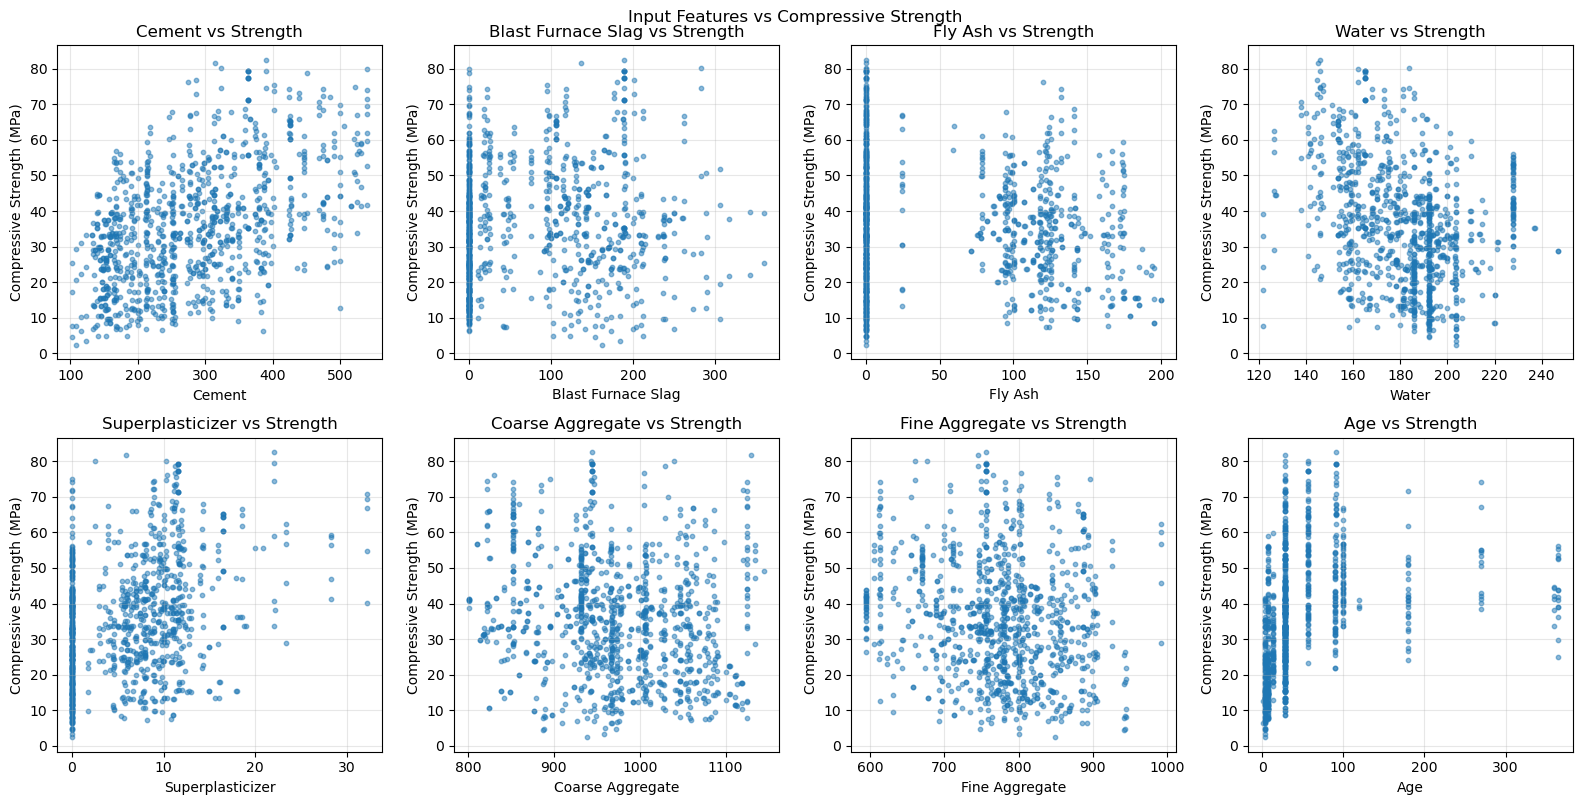

In [ ]:
# Prompt: visualize the compressive strength vs input features as a scatter plot for each feature

# Plot each feature vs. the target
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

feature_names = ['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 
                 'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 'Age']

for i, feature in enumerate(feature_names):
    axes[i].scatter(df.iloc[:, i], df.iloc[:, -1], alpha=0.5, s=10)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Compressive Strength (MPa)')
    axes[i].set_title(f'{feature} vs Strength')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('Input Features vs Compressive Strength', y=1.00)
plt.show()

Even though the data is seemingly chaotic, we can take a look at how variables **correlate** with each other. I won't get into the math of correlation here - informally, the correlation coefficient is 1 if two variables perfecty increase at the same time, -1 if one increases when the other decreases, and 0 if they're uncorrelated. This let's us quickly visualize whether there are some patterns in our dataset.

Formally, the **Pearson correlation coefficient** measures the strength and direction of the linear relationship between two variables:

$$
r_{xy} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2} \sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}}
$$

Where:
- $x_i, y_i$ are individual data points
- $\bar{x}, \bar{y}$ are the means of $x$ and $y$
- $n$ is the number of data points

You will learn about this if you take some stats classes (hugely important in the age of big data).

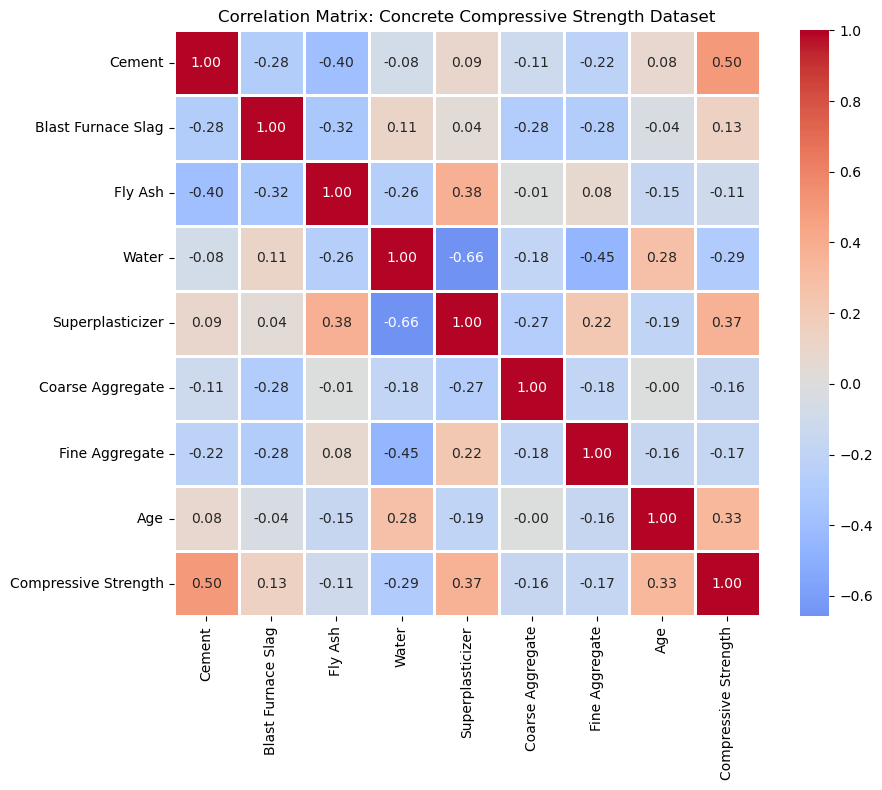

In [ ]:
# Large language model prompt: "visualize the correlation between features in the concrete compressive strength dataset"

import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame with feature names for better visualization
feature_names = ['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 
                 'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 
                 'Age', 'Compressive Strength']

# Combine features and target back into a DataFrame (using original unstandardized data)
import numpy as np
data_for_plot = np.column_stack([df.iloc[:, :-1].values, df.iloc[:, -1].values])
df_plot = pd.DataFrame(data_for_plot, columns=feature_names)

# Create correlation matrix
correlation_matrix = df_plot.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Correlation Matrix: Concrete Compressive Strength Dataset')
plt.tight_layout()
plt.show()

Take a look at the last row, which shows how compressive strength correlates with the various input variables. This plot reveals that even though any individual input/output relationship isn't clear, there are a number of inputs that are weakly correlated with the compressive strength. That tells us that we may have a shot at using a neural network - it could be that there is a complicated relationship between all of these weakly correlated variables that would be hard for us to model but possible for the neural network to pull out.

## TODO: Modify your code to fit an MLP to the concrete dataset

I've included a training loop here that makes the necessary modifications to handle the concrete dataset:
- There are 8 inputs, so we hand `input_dim=8` to the model initializer.
- I've left `learning_rate`, `num_steps`, `batch_size` and `hidden_dim` for you to find good parameters for.

**Your job: fit both the two layer tanh and the three layer ReLU network to this data.**

In [ ]:
# Initialize MLP model for concrete data
model = MLP_modelClass(input_dim=8, hidden_dim=40, output_dim=1)

# Training parameters
learning_rate = 0.1
num_steps = 20
batch_size = 1

for step in range(num_steps):
    # Zero gradients at the start of each step
    if model.W1.grad is not None:
        model.W1.grad.zero_()
        model.b1.grad.zero_()
        model.W2.grad.zero_()
        model.b2.grad.zero_()
    
    # Accumulate loss as a tensor
    total_loss = torch.tensor(0.0, requires_grad=True)
    
    # Randomly select batch_size data points
    for j in range(batch_size):
        i = torch.randint(0, len(X), (1,)).item()
        
        x = X[i]  # Get the i-th feature vector (8 features)
        y_true = y[i]  # Get the i-th target value
        
        # Forward pass
        y_pred = model.forward(x)
        
        # Compute loss and add to total (keep as tensor)
        loss = (y_pred - y_true)**2
        total_loss = total_loss + loss.sum()
    
    # Backward pass on the accumulated loss
    total_loss.backward()
    
    # Update parameters
    with torch.no_grad():
        model.W1 -= learning_rate * model.W1.grad
        model.b1 -= learning_rate * model.b1.grad
        model.W2 -= learning_rate * model.W2.grad
        model.b2 -= learning_rate * model.b2.grad
    
    # Print progress every 1000 steps
    if step % 1000 == 0:
        print(f"Step {step}, Avg Loss: {total_loss.item()/batch_size:.4f}")

        # Loss on entire dataset
        total_loss = torch.tensor(0.0, requires_grad=False)
        for i in range(len(X)):
            x = X[i]
            y_true = y[i]
            
            # Forward pass
            y_pred = model.forward(x)
            
            # Compute loss and add to total
            loss = (y_pred - y_true)**2
            total_loss = total_loss + loss.sum()
        print(f"Avg Loss on entire dataset: {total_loss.item()/len(X):.4f}")

Step 0, Avg Loss: 1332.5361
Avg Loss on entire dataset: 1047.6792
Step 1000, Avg Loss: 14.4832
Avg Loss on entire dataset: 25.2077
Step 2000, Avg Loss: 3.8836
Avg Loss on entire dataset: 17.1081
Step 3000, Avg Loss: 17.7506
Avg Loss on entire dataset: 18.5197
Step 4000, Avg Loss: 10.6137
Avg Loss on entire dataset: 15.1749
Step 5000, Avg Loss: 8.5887
Avg Loss on entire dataset: 12.8814
Step 6000, Avg Loss: 5.1136
Avg Loss on entire dataset: 12.8675
Step 7000, Avg Loss: 11.8848
Avg Loss on entire dataset: 10.8935
Step 8000, Avg Loss: 11.3387
Avg Loss on entire dataset: 9.9710
Step 9000, Avg Loss: 5.8224
Avg Loss on entire dataset: 10.8147
Step 10000, Avg Loss: 5.1557
Avg Loss on entire dataset: 9.6868
Step 11000, Avg Loss: 5.8163
Avg Loss on entire dataset: 9.3293
Step 12000, Avg Loss: 9.1705
Avg Loss on entire dataset: 9.2087
Step 13000, Avg Loss: 17.4547
Avg Loss on entire dataset: 8.4616
Step 14000, Avg Loss: 7.2423
Avg Loss on entire dataset: 8.8520
Step 15000, Avg Loss: 7.3097
Avg 

### Visualize your results

The following block of code will make a plot with your prediction on the y-axis and the true data on the x-axis. You can use this to quickly visualize how well your model is able to predict the data.

You should generate two figures corresponding to the tanh and the ReLU network.

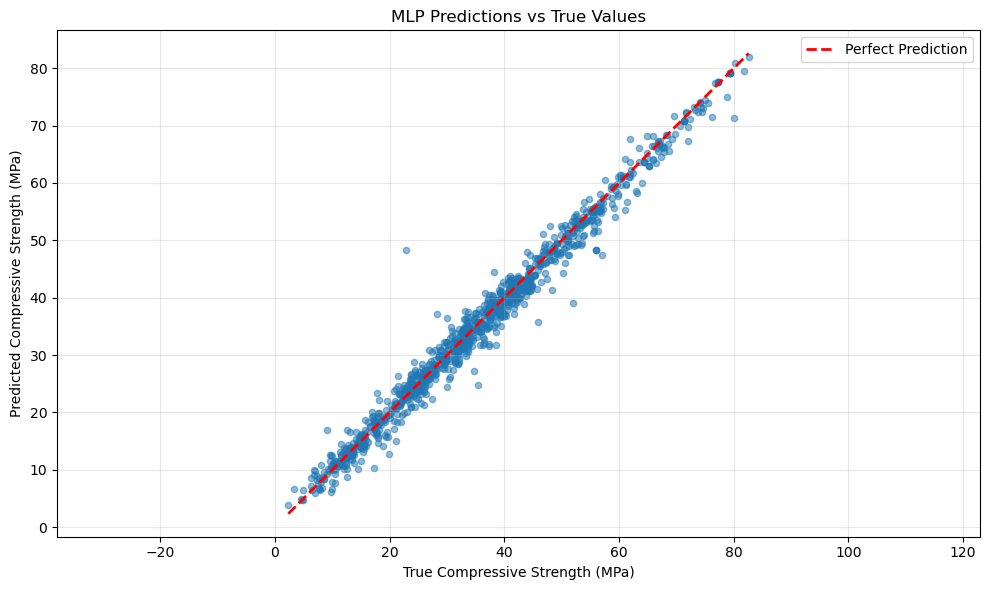


Prediction Quality Metrics:
Mean Squared Error (MSE): 5.09
Root Mean Squared Error (RMSE): 2.26 MPa
Mean Absolute Error (MAE): 1.54 MPa


In [35]:
# Visualize prediction quality
plt.figure(figsize=(10, 6))

# Generate predictions for all data points
y_pred_all = []
y_true_all = []

with torch.no_grad():  # Don't need gradients for evaluation
    for i in range(len(X)):
        x = X[i]
        y_true_val = y[i]
        
        # Forward pass
        y_pred_val = model.forward(x)
        
        y_pred_all.append(y_pred_val.item())
        y_true_all.append(y_true_val.item())

# Convert to numpy for plotting
y_pred_all = np.array(y_pred_all)
y_true_all = np.array(y_true_all)

# Scatter plot: predicted vs true
plt.scatter(y_true_all, y_pred_all, alpha=0.5, s=20)

# Plot perfect prediction line (y=x)
min_val = min(y_true_all.min(), y_pred_all.min())
max_val = max(y_true_all.max(), y_pred_all.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('True Compressive Strength (MPa)')
plt.ylabel('Predicted Compressive Strength (MPa)')
plt.title('MLP Predictions vs True Values')
plt.legend()
plt.grid(alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

# Print some statistics
mse = np.mean((y_pred_all - y_true_all)**2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_pred_all - y_true_all))
print(f"\nPrediction Quality Metrics:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} MPa")
print(f"Mean Absolute Error (MAE): {mae:.2f} MPa")

# Submit today's work 

You should produce **two figures** of predicted vs true compressive strength, corresponding to the:
1. Two-layer tanh network
2. Three-layer MLP network

Today's assignment will be completed individually to make sure we all understand the basic moving pieces of how to use a neural network. You are welcome to discuss with your neighbors and use Gemini to get help with syntax and code explanations. Remember that there will be an exam soon that will check your basic understanding of Pytorch - if you just copy paste Gemini/GPT without getting explanations from me and the TA when you're lost, you will have a bad time on the exam.

Submit to Canvas using the following [link](https://canvas.upenn.edu/courses/1881448/assignments/14098903).